# Baseline 4: ViT-Base/16

This notebook contains the code for training a **Vision Transformer (ViT-Base/16)** model on our preprocessed face crops. ViT is fundamentally different from the CNN baselines. It splits each frame into 16x16 patches and processes them with self-attention instead of convolutions, so it provides a useful architectural contrast in our comparison.

Same frame-level setup as Xception and EfficientNet: run on each of the 24 frames, average the per-frame logits. The only thing that changes is the backbone.

**Approach:** Frame-level Transformer. Run ViT-Base/16 on each of the 24 frames, average the per-frame logits.

**Reference:** Dosovitskiy et al., *"An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale"*, ICLR 2021.

### To view TensorBoard
In PowerShell, use the following command:
```powershell
tensorboard --logdir ./results
```
Open http://localhost:6006 in your browser.

## 1. Setup

In [1]:
# Keep track of time
import time

start_time = time.perf_counter()

In [2]:
# Import nercessary libraries and the shared utilities
import json
from pathlib import Path
import random

import numpy as np
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import timm

# Import shared utilities
from utils import (
    PREPROCESSED_TENSORS_DIR_PATH,
    RESULTS_DIR_PATH,
    DeepfakeClipDataset,
    make_balanced_sampler,
    run_training,
    evaluate,
    load_checkpoint,
    plot_training_curves,
)

In [3]:
# Set the seed value
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Enable cuDNN auto-tuner to select the fastest convolution algorithms
torch.backends.cudnn.benchmark = True

In [4]:
# Set the device
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"GPU Name is:{torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"

GPU Name is:NVIDIA GeForce RTX 5080


In [5]:
# Set the hyper-parameter
model_name = "vit_base_baseline"
# number_of_epochs = 2 # For dry-run
number_of_epochs = 25
batch_size = 4 # ViT-Base/16 is much heavier per frame than Xception/EfficientNet. 4 clips × 24 frames = 96 frames per batch fits in 16GB VRAM with mixed precision; 8 would OOM.
learning_rate = 1e-4
weight_decay = 1e-4
early_stopping_patience = 5

## 2. Build datasets and dataloaders

We use the balanced sampler on the train split to oversample reals (since fakes outnumber them 4:1).

In [6]:
# Build the dataset
splits_json_path = PREPROCESSED_TENSORS_DIR_PATH / "splits.json"
assert splits_json_path.exists(), f"Missing {splits_json_path}."

train_dataset = DeepfakeClipDataset(splits_json_path, "train", PREPROCESSED_TENSORS_DIR_PATH, training_augment=True)
validation_dataset = DeepfakeClipDataset(splits_json_path, "validation", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False)
test_dataset = DeepfakeClipDataset(splits_json_path, "test", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False)

print(f"Train: {len(train_dataset)} clips")
print(f"validation:   {len(validation_dataset)} clips")
print(f"Test:  {len(test_dataset)} clips")

Train: 2799 clips
validation:   349 clips
Test:  351 clips


In [7]:
# Make the training dataset balanced
train_sampler = make_balanced_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

## 3. Define the model

We use the ViT-Base/16 backbone from `timm` (pretrained on ImageNet), then replace its classifier with a single-output head, then wrap it so it accepts clip tensors of shape `[B, T, 3, H, W]` and averages over the time dimension.

ViT-Base has about 86M parameters. That is, larger than Xception (~22M) and EfficientNet-B3 (~12M), so we use a smaller batch size to fit in VRAM.

In [8]:
class ViTFrameAverager(nn.Module):
    """Run ViT-Base/16 on each frame independently, average the logits to get a clip score."""
    
    def __init__(self, pretrained=True):
        super().__init__()
        # timm's 'vit_base_patch16_224' is the ImageNet-pretrained ViT-Base with 16x16 patches at 224 input.
        self.backbone = timm.create_model("vit_base_patch16_224", pretrained=pretrained, num_classes=1)
    
    def forward(self, clip):
        # clip: [B, T, 3, H, W]
        batch_size, number_of_frames, channels, height, width = clip.shape
        
        # Flatten time into batch: [B*T, 3, H, W]
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        
        # Run ViT on every frame: Output: [B*T, 1]
        per_frame_logits = self.backbone(flat_frames)
        
        # Reshape back: [B, T, 1] and average over time
        per_frame_logits = per_frame_logits.view(batch_size, number_of_frames, -1)
        clip_logits = per_frame_logits.mean(dim=1)  # [B, 1]
        return clip_logits


model = ViTFrameAverager(pretrained=True).to(DEVICE)

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_parameters:,}  ({num_parameters/1e6:.1f}M)")

Trainable parameters: 85,799,425  (85.8M)


## 4. Optimizer, scheduler, loss

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# We use Cosine annealing as it gradually decays the LR over the training run
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=number_of_epochs)

loss_function = nn.BCEWithLogitsLoss()

print(f"Optimizer: AdamW, lr={learning_rate}, weight_decay={weight_decay}")
print(f"Scheduler: CosineAnnealingLR over {number_of_epochs} epochs")
print(f"Loss: BCEWithLogitsLoss")

Optimizer: AdamW, lr=0.0001, weight_decay=0.0001
Scheduler: CosineAnnealingLR over 25 epochs
Loss: BCEWithLogitsLoss


## 5. Train

The `run_training` helper from `utils.py` handles the full loop. That is, training epochs, validation, TensorBoard logging, early stopping, and saving the best checkpoint.

Expected wall-clock on RTX 5080: roughly 60–80 minutes for 25 epochs. ViT-Base is the heaviest of the four baselines, and we're running it at batch 4 to fit in VRAM.

In [10]:
best_checkpoint_path = run_training(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_function=loss_function,
    device=DEVICE,
    model_name=model_name,
    number_of_epochs=number_of_epochs,
    early_stopping_patience=early_stopping_patience,
    use_mixed_precision=True,
)


Training: vit_base_baseline
TensorBoard logs: results\vit_base_baseline\tensorboard
  Run `tensorboard --logdir C:\x-ion\TEST\results` to view live curves.



Epoch  1/25  train_loss=0.7481  validation_loss=0.7012  validation_auc=0.5138  validation_acc=0.3238  (1979.4s)


Epoch  2/25  train_loss=0.7095  validation_loss=0.6215  validation_auc=0.5129  validation_acc=0.7994  (1912.5s)


Epoch  3/25  train_loss=0.7055  validation_loss=0.8352  validation_auc=0.5861  validation_acc=0.2006  (1914.1s) *


Epoch  4/25  train_loss=0.7064  validation_loss=0.6546  validation_auc=0.5302  validation_acc=0.7994  (1912.6s)


...

Epoch 21/25  train_loss=0.5641  validation_loss=0.6887  validation_auc=0.7170  validation_acc=0.6361  (145.9s) *


Epoch 22/25  train_loss=0.5460  validation_loss=0.5975  validation_auc=0.7099  validation_acc=0.7077  (145.9s)


Epoch 23/25  train_loss=0.5167  validation_loss=0.6665  validation_auc=0.7071  validation_acc=0.6504  (145.9s)


Epoch 24/25  train_loss=0.5170  validation_loss=0.6324  validation_auc=0.7075  validation_acc=0.6848  (145.9s)


Epoch 25/25  train_loss=0.5131  validation_loss=0.6199  validation_auc=0.7078  validation_acc=0.6934  (145.6s)

Training done. Best vvalidation AUC: 0.7170
Best checkpoint: results\vit_base_baseline\best_model.pt


## 6. Plot training curves

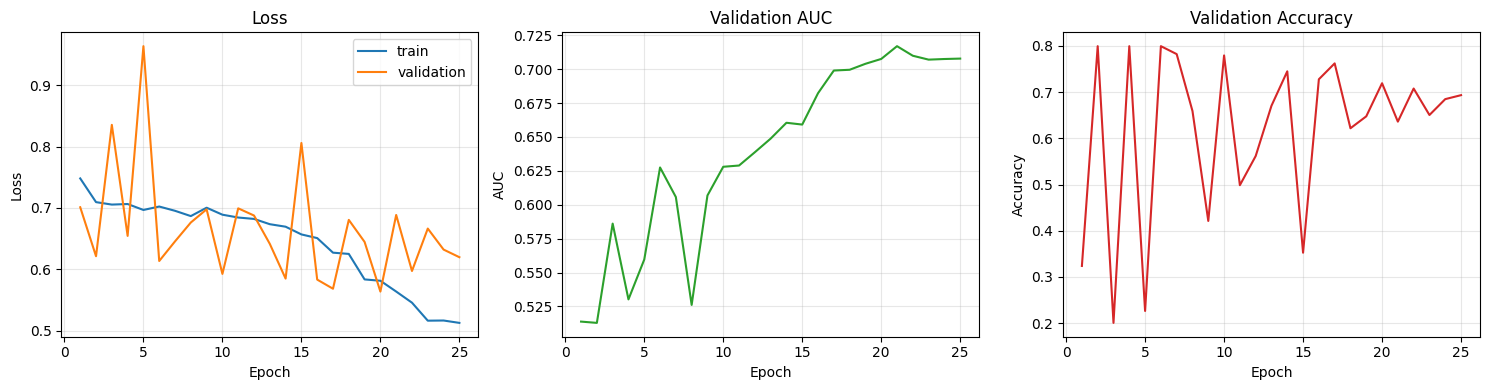

In [11]:
history_path = RESULTS_DIR_PATH / model_name / "training_history.json"
curves_save_path = RESULTS_DIR_PATH / model_name / "training_curves.png"
plot_training_curves(history_path, save_path=curves_save_path)

## 7. Test-set evaluation

Load the best checkpoint and evaluate on the held-out test split. This is the number we'll report in the report.

In [12]:
load_checkpoint(model, best_checkpoint_path, DEVICE)
test_loss, test_metrics, test_predictions = evaluate(model, test_loader, loss_function, DEVICE)

print("\n=== Test set results ===")
print(f"Loss:      {test_loss:.4f}")
print(f"AUC:       {test_metrics['auc']:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1:        {test_metrics['f1']:.4f}")
print(f"Confusion matrix [[TN, FP], [FN, TP]]: {test_metrics['confusion_matrix']}")

# Save for later aggregation across all models
test_metrics_save_path = RESULTS_DIR_PATH / model_name / "final_test_metrics.json"
with open(test_metrics_save_path, "w") as f:
    json.dump({"test_loss": test_loss, "test_metrics": test_metrics}, f, indent=2)

# Also save per-sample predictions for the per-class breakdown later
predictions_save_path = RESULTS_DIR_PATH / model_name / "test_predictions.json"
with open(predictions_save_path, "w") as f:
    json.dump(test_predictions, f, indent=2)

print(f"\nSaved test metrics to {test_metrics_save_path}")


=== Test set results ===
Loss:      0.6836
AUC:       0.7066
Accuracy:  0.6695
Precision: 0.8910
Recall:    0.6690
F1:        0.7642
Confusion matrix [[TN, FP], [FN, TP]]: [[47, 23], [93, 188]]

Saved test metrics to results\vit_base_baseline\final_test_metrics.json


## 8. Per-manipulation breakdown

Split test-set predictions by manipulation method. This will tells us which fake types ViT handles best.

In [13]:
# Group predictions by class name
predictions_by_class = defaultdict(list)
labels_by_class = defaultdict(list)
for probability, true_label, class_name in zip(
    test_predictions["predicted_probs"],
    test_predictions["true_labels"],
    test_predictions["class_names"],
):
    predictions_by_class[class_name].append(probability)
    labels_by_class[class_name].append(true_label)

print("\n=== Per-class accuracy on test set (threshold = 0.5) ===")
print(f"{'Class':<20} {'N':>4}  {'Accuracy':>10}  {'Mean prob':>10}")
print("-" * 50)
for cls_name in sorted(predictions_by_class.keys()):
    probs = np.array(predictions_by_class[cls_name])
    true_labels = np.array(labels_by_class[cls_name])
    predicted = (probs >= 0.5).astype(int)
    accuracy = (predicted == true_labels).mean()
    print(f"{cls_name:<20} {len(probs):>4}  {accuracy:>10.4f}  {probs.mean():>10.4f}")


=== Per-class accuracy on test set (threshold = 0.5) ===
Class                   N    Accuracy   Mean prob
--------------------------------------------------
Deepfakes              71      0.9014      0.7221
Face2Face              70      0.6714      0.5914
FaceSwap               70      0.5286      0.4913
NeuralTextures         70      0.5714      0.5210
original               70      0.6714      0.3991


In [14]:
end_time = time.perf_counter()
time_elapsed = end_time - start_time
hours_elapsed = int(time_elapsed // 3600)
minutes_elapsed = int((time_elapsed % 3600) // 60)

print(f"Total execution time for {model_name}: {hours_elapsed:,}h {minutes_elapsed}m")

Total execution time for vit_base_baseline: 5h 38m
